✅ Data loaded — shape (24, 16)
   Train (520, 24, 16)  Val (112, 24, 16)  Test (112, 24, 16)

  Training: LSTM MODEL

Epoch 1/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0057 - mae: 0.0728 - val_loss: 0.0142 - val_mae: 0.1644 - learning_rate: 0.0010
Epoch 2/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.6956e-04 - mae: 0.0276 - val_loss: 0.0066 - val_mae: 0.1110 - learning_rate: 0.0010
Epoch 3/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.3812e-04 - mae: 0.0227 - val_loss: 0.0071 - val_mae: 0.1153 - learning_rate: 0.0010
Epoch 4/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.4103e-04 - mae: 0.0227 - val_loss: 0.0087 - val_mae: 0.1286 - learning_rate: 0.0010
Epoch 5/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.9380e-04 - mae: 0.0209 - val_loss: 0.0057 - val_mae: 0.1030 - learning_rate: 0.0010
Epoch 6/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.8695e-04 - mae: 0.0192 - val_loss: 0.0058 - val_mae: 0.1038 - learning_rate: 0.0010
Epoch 7/15

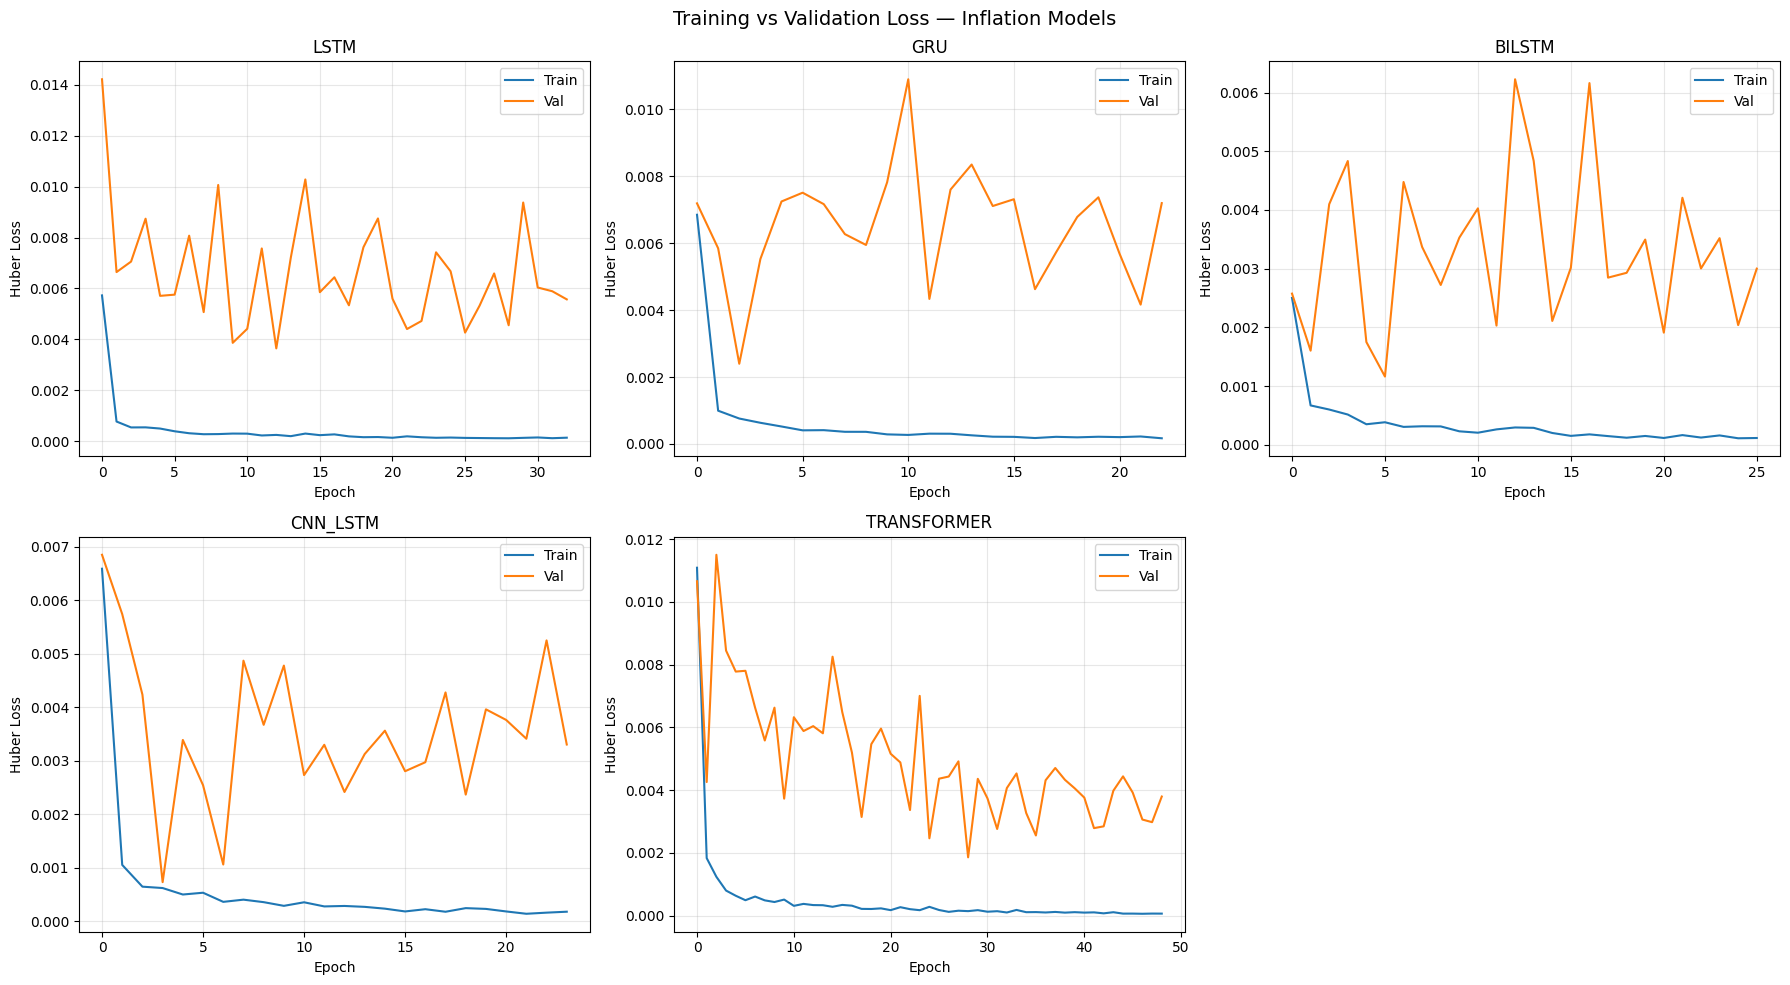


✅ All 5 models trained and saved to models/


In [1]:
# ============================================================
#  NOTEBOOK 3 — Train All Deep Learning Models  (1 Cell)
# ============================================================
import os, numpy as np, matplotlib.pyplot as plt
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional,
    Conv1D, MaxPooling1D, Input,
    MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Add
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

os.makedirs("models", exist_ok=True)
os.makedirs("plots",  exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")
X_val   = np.load("data/X_val.npy")
y_val   = np.load("data/y_val.npy")
X_test  = np.load("data/X_test.npy")
y_test  = np.load("data/y_test.npy")

SEQ_LEN    = X_train.shape[1]
N_FEATURES = X_train.shape[2]
print(f"✅ Data loaded — shape ({SEQ_LEN}, {N_FEATURES})")
print(f"   Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")

# ── Callbacks ─────────────────────────────────────────────────────────────────
def get_callbacks(name):
    return [
        EarlyStopping(patience=20, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(patience=10, factor=0.5, min_lr=1e-6, verbose=0),
        ModelCheckpoint(f"models/{name}.keras", save_best_only=True, verbose=0)
    ]

# ── Model 1: Stacked LSTM ─────────────────────────────────────────────────────
def build_lstm(seq_len, n_feat):
    m = Sequential([
        Input(shape=(seq_len, n_feat)),
        LSTM(128, return_sequences=True), Dropout(0.2),
        LSTM(64,  return_sequences=True), Dropout(0.2),
        LSTM(32),                         Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1)
    ], name="LSTM")
    m.compile(optimizer=Adam(1e-3), loss="huber", metrics=["mae"])
    return m

# ── Model 2: GRU ─────────────────────────────────────────────────────────────
def build_gru(seq_len, n_feat):
    m = Sequential([
        Input(shape=(seq_len, n_feat)),
        GRU(128, return_sequences=True), Dropout(0.2),
        GRU(64,  return_sequences=True), Dropout(0.2),
        GRU(32),                         Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1)
    ], name="GRU")
    m.compile(optimizer=Adam(1e-3), loss="huber", metrics=["mae"])
    return m

# ── Model 3: Bidirectional LSTM ───────────────────────────────────────────────
def build_bilstm(seq_len, n_feat):
    m = Sequential([
        Input(shape=(seq_len, n_feat)),
        Bidirectional(LSTM(128, return_sequences=True)), Dropout(0.2),
        Bidirectional(LSTM(64,  return_sequences=True)), Dropout(0.2),
        Bidirectional(LSTM(32)),                         Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1)
    ], name="BiLSTM")
    m.compile(optimizer=Adam(1e-3), loss="huber", metrics=["mae"])
    return m

# ── Model 4: CNN-LSTM ─────────────────────────────────────────────────────────
def build_cnn_lstm(seq_len, n_feat):
    inp = Input(shape=(seq_len, n_feat))
    x   = Conv1D(64, kernel_size=3, activation="relu", padding="same")(inp)
    x   = Conv1D(64, kernel_size=3, activation="relu", padding="same")(x)
    x   = MaxPooling1D(pool_size=2)(x)
    x   = Dropout(0.2)(x)
    x   = LSTM(64, return_sequences=True)(x)
    x   = Dropout(0.2)(x)
    x   = LSTM(32)(x)
    x   = Dropout(0.2)(x)
    x   = Dense(32, activation="relu")(x)
    x   = Dense(16, activation="relu")(x)
    out = Dense(1)(x)
    m   = Model(inp, out, name="CNN_LSTM")
    m.compile(optimizer=Adam(1e-3), loss="huber", metrics=["mae"])
    return m

# ── Model 5: Transformer ──────────────────────────────────────────────────────
def transformer_block(x, d_model, num_heads, ff_dim, dropout=0.1):
    attn = MultiHeadAttention(num_heads=num_heads,
                              key_dim=d_model // num_heads)(x, x)
    attn = Dropout(dropout)(attn)
    x    = LayerNormalization(epsilon=1e-6)(Add()([x, attn]))
    ff   = Dense(ff_dim, activation="relu")(x)
    ff   = Dense(d_model)(ff)
    ff   = Dropout(dropout)(ff)
    x    = LayerNormalization(epsilon=1e-6)(Add()([x, ff]))
    return x

def build_transformer(seq_len, n_feat,
                       d_model=64, num_heads=4,
                       ff_dim=128, num_blocks=2):
    inp = Input(shape=(seq_len, n_feat))
    x   = Dense(d_model)(inp)
    for _ in range(num_blocks):
        x = transformer_block(x, d_model, num_heads, ff_dim)
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation="relu")(x)
    x   = Dropout(0.1)(x)
    x   = Dense(32, activation="relu")(x)
    x   = Dense(16, activation="relu")(x)
    out = Dense(1)(x)
    m   = Model(inp, out, name="Transformer")
    m.compile(optimizer=Adam(5e-4), loss="huber", metrics=["mae"])
    return m

# ── Train all models ──────────────────────────────────────────────────────────
CONFIGS = [
    ("lstm_model",        build_lstm),
    ("gru_model",         build_gru),
    ("bilstm_model",      build_bilstm),
    ("cnn_lstm_model",    build_cnn_lstm),
    ("transformer_model", build_transformer),
]

FIT_KWARGS = dict(
    x               = X_train,
    y               = y_train,
    validation_data = (X_val, y_val),
    epochs          = 150,
    batch_size      = 16,
    verbose         = 1
)

histories = {}
for save_name, builder in CONFIGS:
    print(f"\n{'='*55}")
    print(f"  Training: {save_name.replace('_',' ').upper()}")
    print(f"{'='*55}")
    tf.keras.backend.clear_session()
    model = builder(SEQ_LEN, N_FEATURES)
    hist  = model.fit(**FIT_KWARGS, callbacks=get_callbacks(save_name))
    histories[save_name] = hist
    print(f"✅ Saved → models/{save_name}.keras")

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, hist) in enumerate(histories.items()):
    axes[i].plot(hist.history["loss"],     label="Train", linewidth=1.5)
    axes[i].plot(hist.history["val_loss"], label="Val",   linewidth=1.5)
    axes[i].set_title(name.replace("_model","").upper())
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Huber Loss")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

axes[5].axis("off")
plt.suptitle("Training vs Validation Loss — Inflation Models", fontsize=14)
plt.tight_layout()
plt.savefig("plots/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ All 5 models trained and saved to models/")